In [12]:
import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression #NOT USED
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:

MAX_ITERATIONS = 1000
TEST_SIZE = 0.3


df = pd.read_csv('CustomerStats.csv')

# THIS IS USED FOR RFM_RANK
# TODO: 'ProductGroup', 'ProductCode' Encode these 
# Split features (X) and target variable (y)

# Drop columns with NaN values
df = df.dropna(axis=1)

# Split features (X) and target variable (y)
y = df['RFM_Rank']
X = df.drop(columns=['LocationName', 'BranchName',
        'ProductGroup', 'ProductCode', 'CustomerName', 'SalesDate', 'RFM_Rank'])


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=None, shuffle=True)

# Train the model
model = LogisticRegression(max_iter=MAX_ITERATIONS)

model.fit(X_train, y_train)

# Evaluate the model
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print('Accuracy of the classifier on the training set: {:.2f}'.format(train_accuracy))
print('Accuracy of the classifier on the test set: {:.2f}'.format(test_accuracy))

# Example of calculating mean squared error (MSE) for linear regression

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print('Mean Squared Error (MSE) on the training set: {:.2f}'.format(train_mse))
print('Mean Squared Error (MSE) on the test set: {:.2f}'.format(test_mse))

# Compare predicted RFM ranks with actual RFM ranks including customer code
train_comparison = pd.DataFrame({'CustomerCode': X_train['CustomerCode'], 'Actual RFM Rank': y_train, 'Predicted RFM Rank': train_predictions})
test_comparison = pd.DataFrame({'CustomerCode': X_test['CustomerCode'], 'Actual RFM Rank': y_test, 'Predicted RFM Rank': test_predictions})

#print('\nComparison of Actual vs Predicted RFM Ranks for Training Set:')
train_mismatch = train_comparison[train_comparison['Actual RFM Rank'] != train_comparison['Predicted RFM Rank']]
#print(train_mismatch)

#print('\nComparison of Actual vs Predicted RFM Ranks for Test Set:')
test_mismatch = test_comparison[test_comparison['Actual RFM Rank'] != test_comparison['Predicted RFM Rank']]
#print(test_mismatch)

# Displaying model performance metrics
print('Model Performance Metrics:')
print('---------------------------------')
print('Accuracy on Training Set: {:.2f}'.format(train_accuracy))
print('Accuracy on Test Set: {:.2f}'.format(test_accuracy))
print('Mean Squared Error (MSE) on Training Set: {:.2f}'.format(train_mse))
print('Mean Squared Error (MSE) on Test Set: {:.2f}'.format(test_mse))
print('---------------------------------\n')

# Displaying comparison of actual vs predicted RFM ranks including customer code
print('Comparison of Actual vs Predicted RFM Ranks with Customer Codes:')
print('---------------------------------')
print('Training Set Mismatches:')
print(train_mismatch)
print('\nTest Set Mismatches:')
print(test_mismatch)
print('---------------------------------')


C:\Users\Aaron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of the classifier on the training set: 0.94
Accuracy of the classifier on the test set: 0.94
Mean Squared Error (MSE) on the training set: 0.21
Mean Squared Error (MSE) on the test set: 0.21
Model Performance Metrics:
---------------------------------
Accuracy on Training Set: 0.94
Accuracy on Test Set: 0.94
Mean Squared Error (MSE) on Training Set: 0.21
Mean Squared Error (MSE) on Test Set: 0.21
---------------------------------

Comparison of Actual vs Predicted RFM Ranks with Customer Codes:
---------------------------------
Training Set Mismatches:
        CustomerCode  Actual RFM Rank  Predicted RFM Rank
127336         13767                5                   6
123451         13718                6                   7
32042          12963                5                   6
1156           12355                5                   6
312500         16374                5                   6
...              ...              ...                 ...
182924         14507      

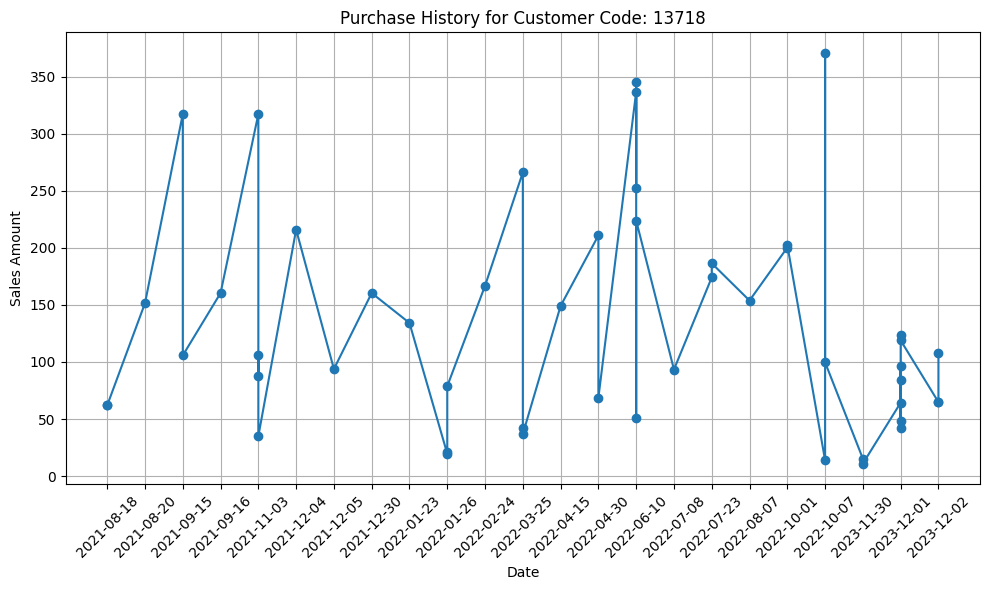

In [32]:
import matplotlib.pyplot as plt

customer_code = 14388
# Filter purchase history for the specified customer code
customer_data = df[df['CustomerCode'] == customer_code]

# Check if customer data is empty
if customer_data.empty:
    print("No purchase history found for customer code:", customer_code)

# Sort purchase history by date
customer_data = customer_data.sort_values(by='SalesDate')

# Plot purchase history
plt.figure(figsize=(10, 6))
plt.plot(customer_data['SalesDate'], customer_data['ExtPrice'], marker='o', linestyle='-')
plt.title('Purchase History for Customer Code: ' + str(customer_code))
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()